In [2]:
import pandas as pd

df = pd.read_excel("bank-data.xlsx")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
0,31,management,single,tertiary,no,0,yes,no,cellular,15,apr,185,2,-1,0,unknown,no
1,45,entrepreneur,married,tertiary,no,1752,yes,yes,cellular,20,nov,56,2,-1,0,unknown,no
2,46,services,divorced,secondary,no,4329,no,no,cellular,21,nov,534,2,-1,0,unknown,yes
3,35,management,married,tertiary,no,1108,yes,no,cellular,17,nov,52,1,-1,0,unknown,no
4,39,management,married,secondary,no,1410,yes,no,unknown,23,may,55,1,-1,0,unknown,no


Accuracy: 0.905

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95       537
           1       0.65      0.21      0.31        63

    accuracy                           0.91       600
   macro avg       0.78      0.60      0.63       600
weighted avg       0.89      0.91      0.88       600


Confusion Matrix:
 [[530   7]
 [ 50  13]]


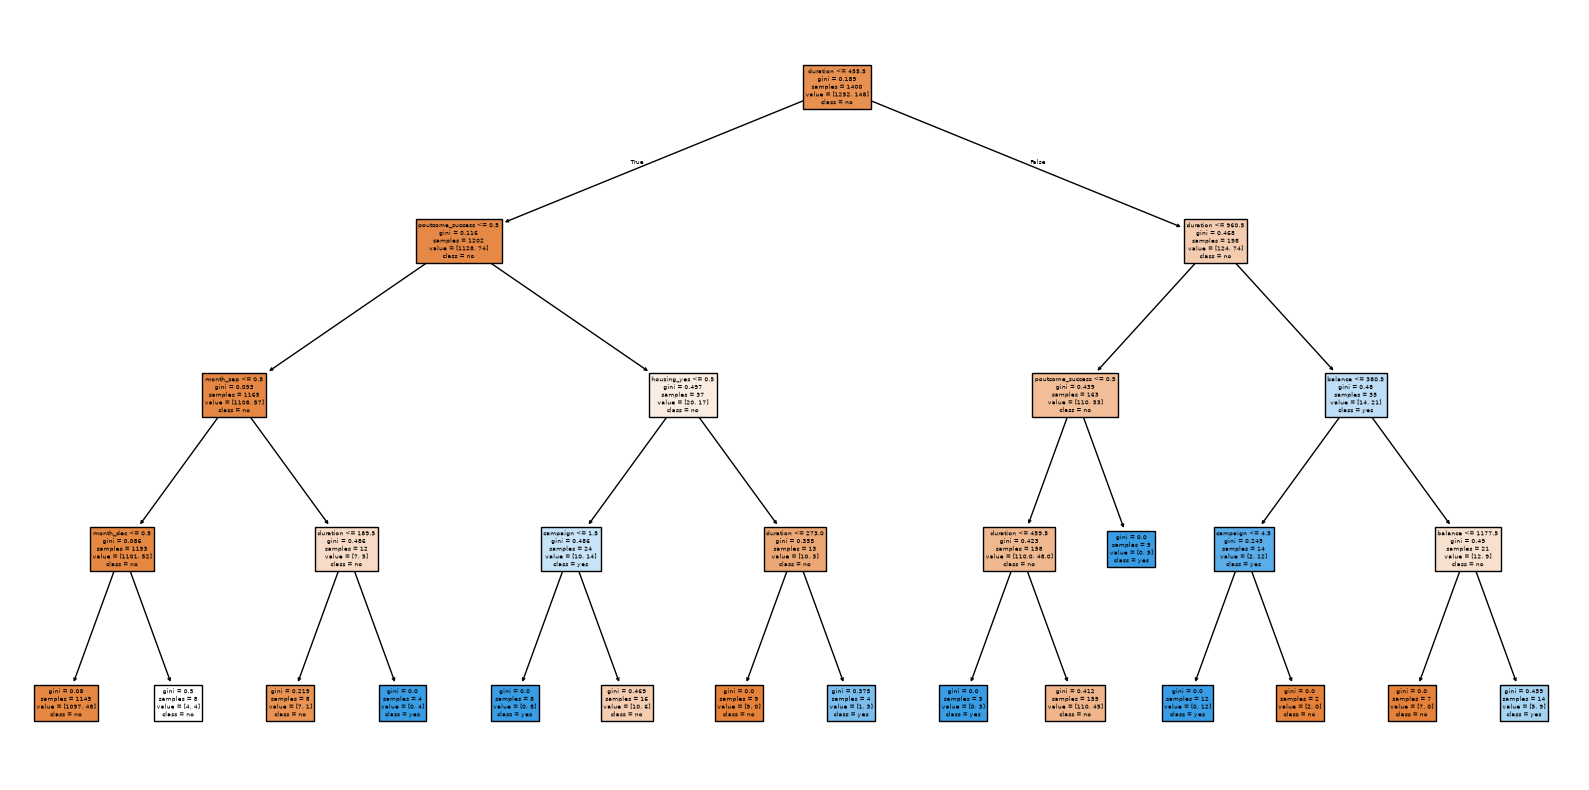

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import tree
import matplotlib.pyplot as plt

# Load data
# df = pd.read_excel("bank-data.xlsx")

# Prepare features and target
X = df.drop(columns=["subscribed"])
y = df["subscribed"].map({"yes": 1, "no": 0})

# Convert categorical features to numeric using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train the decision tree classifier
model = DecisionTreeClassifier(random_state=42, max_depth=4)
model.fit(X_train, y_train)

# Make predictions and evaluate the model
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: visualize the decision tree
fig, ax = plt.subplots(figsize=(16, 8))
tree.plot_tree(
    model,
    feature_names=X.columns,
    class_names=["no", "yes"],
    filled=True,
    ax=ax,
)
plt.tight_layout()
plt.show()


In [3]:
import pandas as pd

pivot_table = pd.crosstab(df['month'], df['subscribed'], margins=True, margins_name='Total')
pivot_table = pivot_table.drop('Total', axis=0)
pivot_sorted = pivot_table.sort_values(by='Total', ascending=False)

print(pivot_sorted)


subscribed   no  yes  Total
month                      
may         552   29    581
jul         306   34    340
aug         243   35    278
jun         212   20    232
nov         171   12    183
apr         103   15    118
feb          92   19    111
jan          62    6     68
oct          19   14     33
sep          12   12     24
dec           8    9     17
mar           9    6     15


In [ ]:
df[df["subscribed"] == 'yes']['duration'].max()

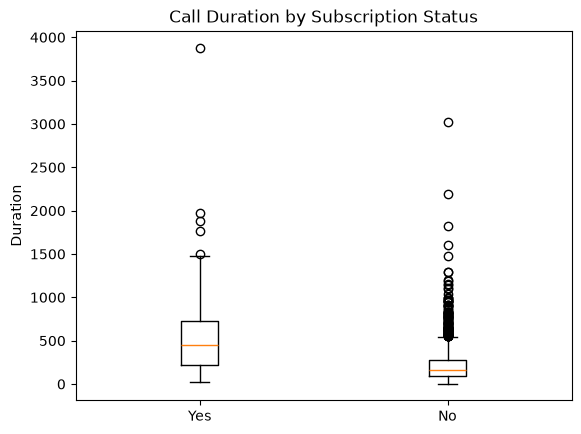

In [3]:
#draw a box plot for the duration of calls for yes and no subscribers
import matplotlib.pyplot as plt

# Using 'tick_labels' instead of 'labels'
plt.boxplot(
    [df[df["subscribed"] == 'yes']['duration'], df[df["subscribed"] == 'no']['duration']], 
    tick_labels=['Yes', 'No']
)
plt.ylabel('Duration')
plt.title('Call Duration by Subscription Status')
plt.show()


In [27]:
#average call durations of yes subscribers and no subscribers
df.groupby('subscribed')['duration'].mean()

subscribed
no     222.375629
yes    539.355450
Name: duration, dtype: float64

In [20]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'subscribed'],
      dtype='object')

In [26]:
# Convert target to 1 and 0 first
df['subscribed_num'] = df['subscribed'].map({'yes': 1, 'no': 0})

# Get subscription rate by profile (sorted highest to lowest)
profile_patterns = df.groupby('job')['subscribed_num'].mean().sort_values(ascending=False)
print(profile_patterns)


job
student          0.305556
unknown          0.200000
unemployed       0.183333
retired          0.173913
entrepreneur     0.128571
management       0.111111
technician       0.106195
admin.           0.097872
blue-collar      0.080460
housemaid        0.079365
services         0.077381
self-employed    0.043478
Name: subscribed_num, dtype: float64


In [17]:
df.age.value_counts()

age
31    92
34    86
35    84
30    83
32    83
      ..
68     1
76     1
77     1
87     1
93     1
Name: count, Length: 65, dtype: int64

In [13]:
df[df["balance"] < 0]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
39,23,blue-collar,single,secondary,yes,-207,yes,no,unknown,3,jun,277,1,-1,0,unknown,no
42,54,management,married,secondary,no,-133,yes,no,cellular,17,apr,76,1,343,2,failure,no
90,24,blue-collar,married,secondary,no,-389,yes,yes,unknown,4,jun,1242,1,-1,0,unknown,yes
100,43,blue-collar,divorced,secondary,no,-91,yes,yes,cellular,7,may,92,3,167,4,other,no
111,49,management,married,tertiary,yes,-24,no,no,cellular,18,nov,132,3,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1965,30,services,single,secondary,yes,-366,yes,no,cellular,18,jul,516,1,-1,0,unknown,yes
1986,28,admin.,divorced,secondary,no,-504,yes,yes,cellular,14,may,578,1,-1,0,unknown,yes
1987,51,management,married,tertiary,no,-714,no,no,cellular,18,jul,83,2,-1,0,unknown,no
1990,32,blue-collar,married,primary,no,-283,yes,no,cellular,18,may,24,2,349,2,other,no


In [11]:
df[(df["balance"] < 0) & (df["subscribed"] == "yes")]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
90,24,blue-collar,married,secondary,no,-389,yes,yes,unknown,4,jun,1242,1,-1,0,unknown,yes
352,40,blue-collar,married,secondary,no,-438,no,no,cellular,11,may,1017,1,-1,0,unknown,yes
479,28,blue-collar,single,secondary,no,-46,yes,no,cellular,1,jun,154,2,91,12,success,yes
859,53,blue-collar,married,primary,yes,-462,no,no,cellular,29,jan,470,1,-1,0,unknown,yes
1023,43,blue-collar,married,primary,no,-192,yes,no,unknown,8,may,1120,2,-1,0,unknown,yes
1277,47,technician,single,secondary,no,-239,yes,yes,cellular,7,jul,973,3,-1,0,unknown,yes
1468,40,blue-collar,married,secondary,no,-839,yes,yes,cellular,16,jul,1018,2,-1,0,unknown,yes
1568,37,entrepreneur,single,secondary,no,-22,yes,no,cellular,15,may,317,1,-1,0,unknown,yes
1965,30,services,single,secondary,yes,-366,yes,no,cellular,18,jul,516,1,-1,0,unknown,yes
1986,28,admin.,divorced,secondary,no,-504,yes,yes,cellular,14,may,578,1,-1,0,unknown,yes


In [2]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="EDA Report")
profile.to_file("eda_report.html")


d:\college\.common_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Nishad\AppData\Local\Temp\ipykernel_29940\3970376816.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport
Export report to file: 100%|██████████| 1/1 [00:00<00:00, 125.01it/s]


In [3]:
import sweetviz as sv

report = sv.analyze(df)
report.show_html("sweetviz_report.html")


Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
